# Import Library

## 
Files required 
1) gamma code = gamma(folder)
2) policy model = policy_model_discreteshift_final_3L_512H_s1_c3.pth
3) reference data = data(folder)
4) moving_average.py
5) GAMMA_obj_temp_depth.py

In [ ]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple
import sys
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os

device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

from moving_average import moving_average_1d
import copy
from GAMMA_obj_temp_depth import GAMMA_obj


cuda is available


# Import Policy Model

In [2]:
from policy import PolicyNN
model = PolicyNN(
    past_input_dim=6,
    future_input_dim=6,
    output_dim=1,
    p=50,
    window=50,
    hidden_dim=512,
    n_layers=3,
    dropout_p=0.1
).to(device)

model.load_state_dict(torch.load("/home/ftk3187/github/DPC_research/02_DED/4_policy_0725/trainresults/policy_model_discreteshift_final_3L_512H_s1_c3.pth", map_location="cpu"))
model.eval()

PolicyNN(
  (input_layer): Linear(in_features=600, out_features=512, bias=True)
  (input_ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=512, out_features=512, bias=True)
  )
  (norm_layers): ModuleList(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (output_layer): Linear(in_features=512, out_features=50, bias=True)
)

# Import Reference Data

In [3]:
INPUT_DATA_DIR = "data"
SIM_DIR_NAME = "single_track_square"
BASE_LASER_FILE_DIR = "laser_power_profiles/csv"
CLOUD_TARGET_BASE_PATH = "result"
solidus_temp = 1600
window = 50
sim_interval = 5
init_runs = 50 #50 

GAMMA_class = GAMMA_obj(INPUT_DATA_DIR, SIM_DIR_NAME, BASE_LASER_FILE_DIR, CLOUD_TARGET_BASE_PATH, solidus_temp, window, init_runs, sim_interval, laser_power_number=1)
init_avg = GAMMA_class.run_initial_steps()
init_avg = torch.tensor(init_avg,dtype=torch.float32)[:,-window:] # shape = [2,50]

100%|██████████| 250/250 [00:06<00:00, 40.37it/s]


In [4]:
df_one_print = pd.read_csv('single_track_ref.csv')

loc_X_list = df_one_print["X"].to_numpy().reshape(-1,1)
loc_Y_list = df_one_print["Y"].to_numpy().reshape(-1,1)
loc_Z_list = df_one_print["Z"].to_numpy().reshape(-1,1)
dist_X_list = df_one_print["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y_list = df_one_print["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
scan_spd_list = df_one_print["scanning_speed"].to_numpy().reshape(-1,1)

# laser power
laser_power_ref = torch.tensor(df_one_print["Laser_power"].to_numpy().reshape(-1,1),dtype=torch.float32)
laser_power_past = laser_power_ref[:window]
fix_covariates = torch.tensor(np.concatenate((loc_Z_list,dist_X_list,dist_Y_list),axis=1),dtype=torch.float32)

# apply moving average for mp temp
mp_temp_raw = df_one_print["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp

mp_temp_ref = torch.tensor(mp_temp,dtype=torch.float32)

# Sub-Function ; Normalize

In [8]:
x_min = torch.tensor([[0.0, 0.75, 0.75, 504.26]], dtype=torch.float32).to(device)
x_max = torch.tensor([[7.5, 20.0, 20.0, 732.298]], dtype=torch.float32).to(device)

y_min = torch.tensor([[436.608, -0.559]], dtype=torch.float32).to(device)
y_max = torch.tensor([[4509.855, 0.551]], dtype=torch.float32).to(device)


In [9]:
def normalize_x(x, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 2 * (x - x_min_selected) / (x_max_selected - x_min_selected) - 1

def inverse_normalize_x(x_norm, dim_id):
    x_min_selected = x_min[0, dim_id]
    x_max_selected = x_max[0, dim_id]
    return 0.5 * (x_norm + 1) * (x_max_selected - x_min_selected) + x_min_selected

def normalize_y(y, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 2 * (y - y_min_selected) / (y_max_selected - y_min_selected) - 1

def inverse_normalize_y(y_norm, dim_id):
    y_min_selected = y_min[0, dim_id]
    y_max_selected = y_max[0, dim_id]
    return 0.5 * (y_norm + 1) * (y_max_selected - y_min_selected) + y_min_selected


# Sub-Function ; Run Policy

In [11]:
def run_one_step_policy(GAMMA_obj, policy_model, P, window):
    # Reference trajectory for temperature (original scale)
    mp_temp_ref = GAMMA_obj.ref[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P]  # [P, 1] or [P]
    mp_temp_ref_t = torch.as_tensor(mp_temp_ref, dtype=torch.float32, device=device).reshape(1, P, 1)  # [1, P, 1]

    # Past input (original scale)
    mp_temp_past_t = GAMMA_obj.x_past.T.unsqueeze(0).to(device)  # [1, 50, 2]
    laser_past_t = GAMMA_obj.u_past.view(1, -1, 1).to(device)     # [1, 50, 1]
    fix_cov_past = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter - window:GAMMA_obj.MPC_counter, :]
    fix_cov_past_t = torch.as_tensor(fix_cov_past, dtype=torch.float32, device=device).unsqueeze(0)  # [1, 50, 3]

    # Normalize
    fix_cov_past_s = normalize_x(fix_cov_past_t, dim_id=[0, 1, 2])    # assume features 0~2 in x
    laser_past_s = normalize_x(laser_past_t, dim_id=[3])              # laser power at feature 3
    mp_temp_past_s = normalize_y(mp_temp_past_t, dim_id=[0, 1])       # temp and depth
    policy_in_past = torch.cat((fix_cov_past_s, laser_past_s, mp_temp_past_s), dim=2)  # [1, 50, 6]

    # Future covariates
    fix_cov_future = GAMMA_obj.fix_cov_all[GAMMA_obj.MPC_counter:GAMMA_obj.MPC_counter + P, :]
    fix_cov_future_t = torch.as_tensor(fix_cov_future, dtype=torch.float32, device=device).unsqueeze(0)  # [1, P, 3]
    fix_cov_future_s = normalize_x(fix_cov_future_t, dim_id=[0, 1, 2])
    mp_temp_ref_s = normalize_y(mp_temp_ref_t, dim_id=[0])[:, :, 0].unsqueeze(-1)

    # constraints!
    depth_lower_const = 0.1423
    depth_upper_const = 0.4126
    y_const_s = torch.tensor([[depth_lower_const, depth_upper_const]] * P, dtype=torch.float32, device=device).reshape(1, P, 2)
    policy_in_future = torch.cat((fix_cov_future_s, mp_temp_ref_s, y_const_s), dim=2)  # [1, P, 6]

    # Policy inference
    u_pred = policy_model((policy_in_past, policy_in_future))
    u_first = u_pred[0,0]
    u_applied = float(inverse_normalize_x(u_first, dim_id=[3]))  # laser power

    # Simulate one step
    x_current, depth_current = GAMMA_obj.run_sim_interval(u_applied)

    # Update past sequence
    GAMMA_obj.x_past[:, :-1] = GAMMA_obj.x_past[:, 1:]
    GAMMA_obj.x_past[0, -1] = x_current
    GAMMA_obj.x_past[1, -1] = depth_current
    GAMMA_obj.u_past[:-1] = GAMMA_obj.u_past[1:].clone()
    GAMMA_obj.u_past[-1] = u_applied

    # Save state
    GAMMA_obj.x_hat_current = torch.tensor([x_current, depth_current], device=device)
    GAMMA_obj.x_sys_current = torch.tensor([[x_current], [depth_current]], device=device)
    GAMMA_obj.MPC_counter += 1

    # FIXED: device-matched saving
    new_state = torch.tensor([[x_current, depth_current]], device=GAMMA_obj.x_past_save.device)
    GAMMA_obj.x_past_save = torch.cat((GAMMA_obj.x_past_save, new_state), dim=0)

    new_u = torch.tensor([[u_applied]], device=GAMMA_obj.u_past_save.device)
    GAMMA_obj.u_past_save = torch.cat((GAMMA_obj.u_past_save, new_u), dim=0)


# Sub-Function ; Plot Rollout

In [12]:
def plot_fig(MPC_GAMMA, N_step):
    plt.figure(figsize=[12,10])
    plt.subplot(3,1,1)
    plt.plot(MPC_GAMMA.x_past_save[:N_step,0], label = "GAMMA simulation")
    plt.plot(MPC_GAMMA.ref[:N_step], label="Reference")
    plt.legend()


    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Temperature (k)")

    plt.subplot(3,1,2)
    plt.plot(MPC_GAMMA.x_past_save[:N_step,1], label = "GAMMA simulation")
    plt.plot(np.linspace(0,N_step,N_step),0.225*np.ones(N_step))
    plt.plot(np.linspace(0,N_step,N_step),0.075*np.ones(N_step))
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend()

    plt.subplot(3,1,3)
    plt.plot(MPC_GAMMA.u_past_save[:N_step])
    plt.ylabel("Laser power (w)")
    plt.xlabel("MPC time step (0.0355 sec/iteration)")
    plt.show()

# Execution

  0%|          | 0/6295 [00:00<?, ?it/s]

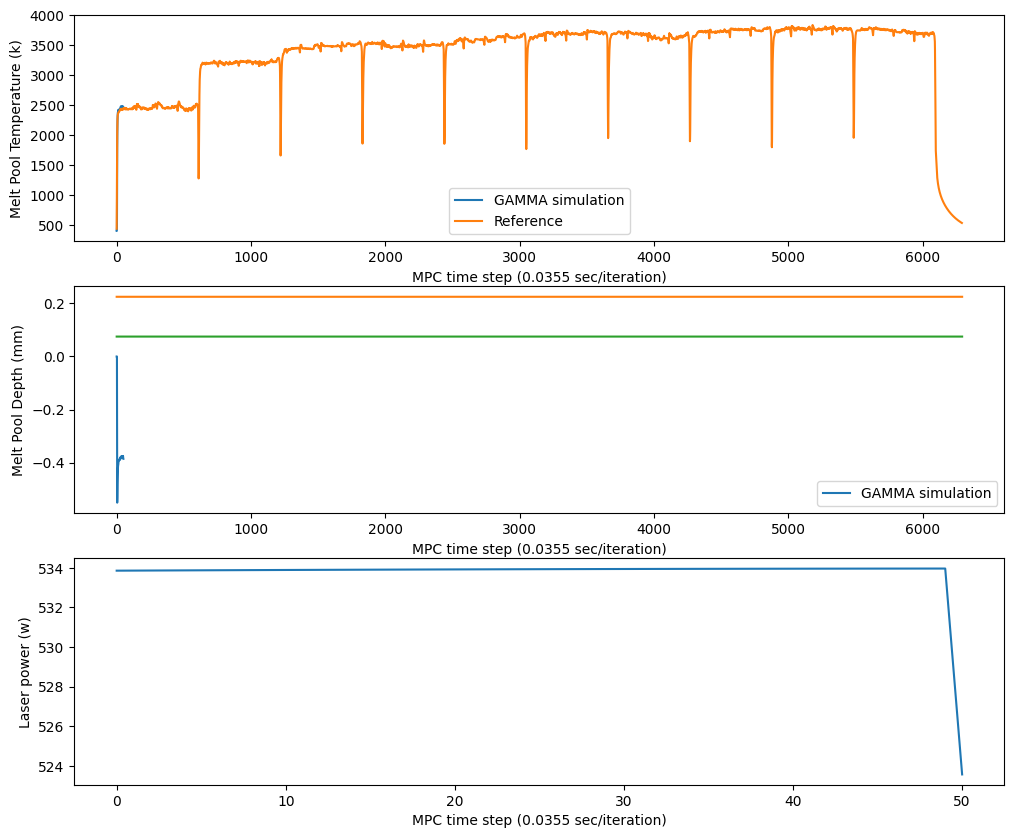

 32%|███▏      | 2000/6295 [04:29<10:13,  7.00it/s]

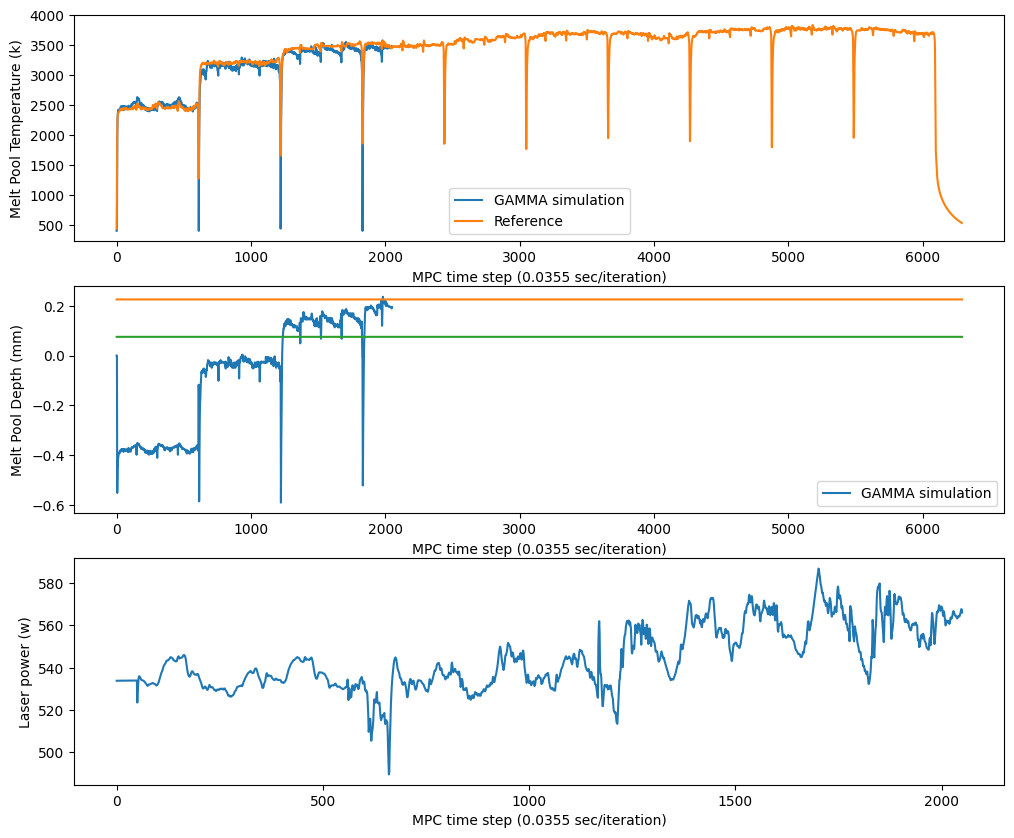

 64%|██████▎   | 4000/6295 [09:31<05:34,  6.86it/s]

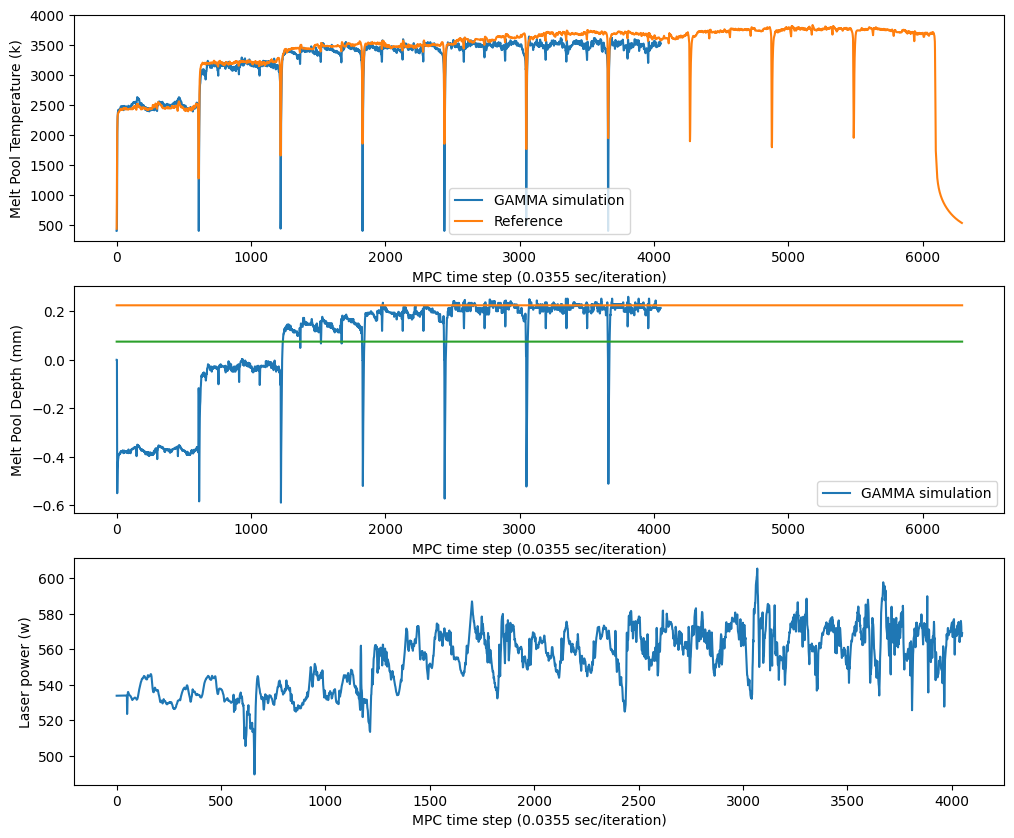

 95%|█████████▌| 6000/6295 [14:50<00:45,  6.43it/s]

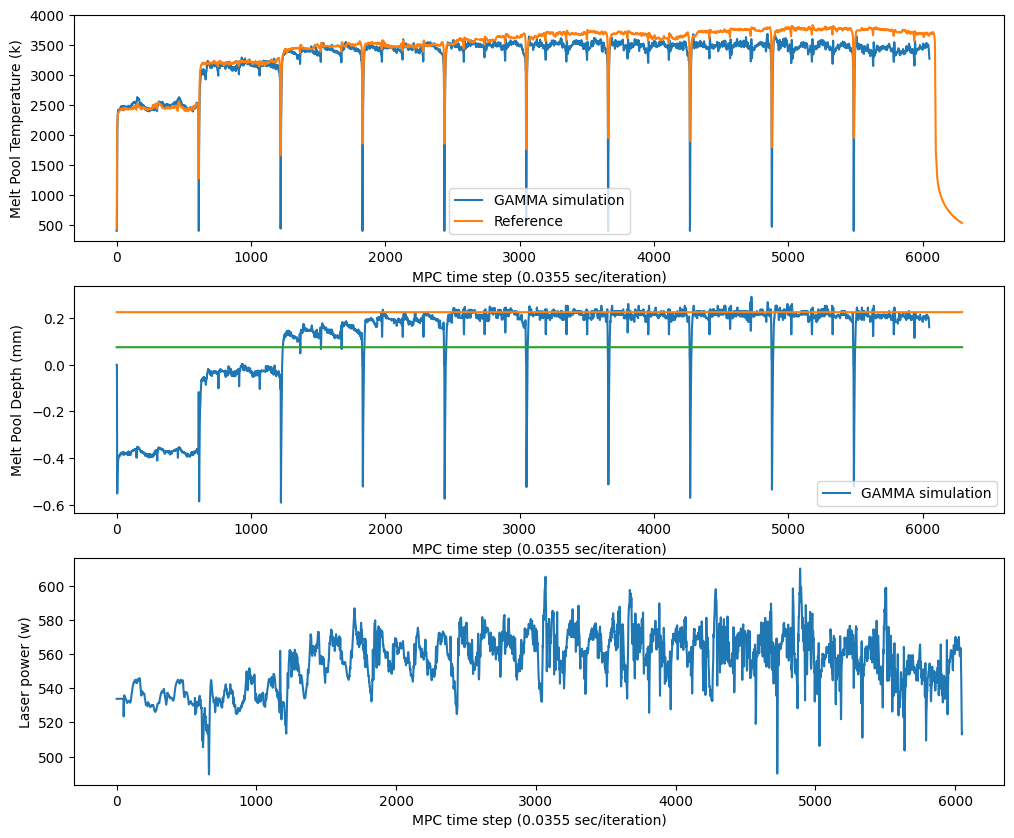

 98%|█████████▊| 6196/6295 [15:20<00:14,  6.73it/s]


RuntimeError: shape '[1, 50, 1]' is invalid for input of size 49

In [13]:
# step #
P = 50
N_step = len(mp_temp_ref) - init_runs + 50


# initialize GAMMA class
GAMMA_class.ref = mp_temp_ref
GAMMA_class.fix_cov_all = fix_covariates
GAMMA_class.x_past = init_avg.clone()
GAMMA_class.u_past = laser_power_past.clone()

GAMMA_class.x_hat_current = GAMMA_class.x_past[:, -1]
GAMMA_class.x_sys_current = GAMMA_class.x_past[:, -1].reshape(2, 1)

GAMMA_class.x_past_save = GAMMA_class.x_past.T.clone()
GAMMA_class.u_past_save = GAMMA_class.u_past.clone()
GAMMA_class.MPC_counter = window 


# execution loop
from tqdm import tqdm

for i in tqdm(range(N_step)):
    run_one_step_policy(GAMMA_class, model, P=P, window=window)

    if i % 2000 == 0:
        plot_fig(GAMMA_class, N_step)
